In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

In [23]:
df = pd.read_csv("Wholesale customers data.csv")
print(df)

     Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
0          2       3  12669   9656     7561     214              2674   
1          2       3   7057   9810     9568    1762              3293   
2          2       3   6353   8808     7684    2405              3516   
3          1       3  13265   1196     4221    6404               507   
4          2       3  22615   5410     7198    3915              1777   
..       ...     ...    ...    ...      ...     ...               ...   
435        1       3  29703  12051    16027   13135               182   
436        1       3  39228   1431      764    4510                93   
437        2       3  14531  15488    30243     437             14841   
438        1       3  10290   1981     2232    1038               168   
439        1       3   2787   1698     2510      65               477   

     Delicassen  
0          1338  
1          1776  
2          7844  
3          1788  
4          5185  
..          ...

In [24]:
df = df.drop(columns=['Channel', 'Region'])
X_raw = df.values
print(X_raw)

[[12669  9656  7561   214  2674  1338]
 [ 7057  9810  9568  1762  3293  1776]
 [ 6353  8808  7684  2405  3516  7844]
 ...
 [14531 15488 30243   437 14841  1867]
 [10290  1981  2232  1038   168  2125]
 [ 2787  1698  2510    65   477    52]]


In [25]:
X = (X_raw - np.mean(X_raw, axis=0)) / np.std(X_raw, axis=0)
print(X)
n_muestras, n_caracteristicas = X.shape
print(n_muestras, n_caracteristicas)
#440 datos con 6 caracteristicas

[[ 0.05293319  0.52356777 -0.04111489 -0.58936716 -0.04356873 -0.06633906]
 [-0.39130197  0.54445767  0.17031835 -0.27013618  0.08640684  0.08915105]
 [-0.44702926  0.40853771 -0.0281571  -0.13753572  0.13323164  2.24329255]
 ...
 [ 0.20032554  1.31467078  2.34838631 -0.54337975  2.51121768  0.12145607]
 [-0.13538389 -0.51753572 -0.60251388 -0.41944059 -0.56977032  0.21304614]
 [-0.72930698 -0.5559243  -0.57322717 -0.62009417 -0.50488752 -0.52286938]]
440 6


In [42]:
def runkMeans(X, k):
  bestInertia = float('inf')
  bestCentroides = np.zeros((k, n_caracteristicas))
  bestEtiquetas = np.zeros(n_muestras, np.int32)
  for c in range(10):
    centroides = np.random.uniform(0.0, 1.0, (k, n_caracteristicas))
    etiquetas = np.zeros(n_muestras, np.int32)
    #print('etiquetas iniciales', etiquetas)
    #print('centroides iniciales', centroides)
    while True:
      #Calcular distancias y etiquetas nuevas
      for i in range(n_muestras):
        distancias = []
        for j in range(k):
          d = np.linalg.norm(X[i] - centroides[j])
          distancias.append(d)
        etiquetas[i] = np.argmin(distancias)
      #Calcular centroides nuevos
      nuevosCentroides = np.zeros((k, n_caracteristicas))
      conteo_puntos_por_cluster = np.zeros(k)
      #print(n_muestras, etiquetas)
      for j in range(n_muestras):
        cluster_asignado = etiquetas[j]
        nuevosCentroides[cluster_asignado] += X[j]
        conteo_puntos_por_cluster[cluster_asignado] += 1
      for i in range(k):
        if conteo_puntos_por_cluster[i] > 0:
            nuevosCentroides[i] = nuevosCentroides[i] / conteo_puntos_por_cluster[i]
        else:
            nuevosCentroides[i] = X[np.random.choice(n_muestras)]
      centroidesMovimiento = np.linalg.norm(nuevosCentroides - centroides)
      if (centroidesMovimiento < 1e-4):
        break
      else:
        centroides = nuevosCentroides.copy()
    inercia = 0
    for i in range(k):
        puntos_en_cluster = X[etiquetas == i]
        if len(puntos_en_cluster) > 0:
            inercia += np.sum(np.linalg.norm(puntos_en_cluster - centroides[i], axis=1) ** 2)
    #print(inercia, centroides)
    if (inercia < bestInertia):
      bestInertia = inercia
      bestCentroides = centroides
      bestEtiquetas = etiquetas
  #print('mejores:', bestInertia, bestCentroides)
  return bestCentroides, bestEtiquetas, bestInertia

La inercia fue de  1954.1835647259281  para K= 2
La inercia fue de  1610.1723291819899  para K= 3
La inercia fue de  1334.294993011372  para K= 4
La inercia fue de  1073.161738078653  para K= 5


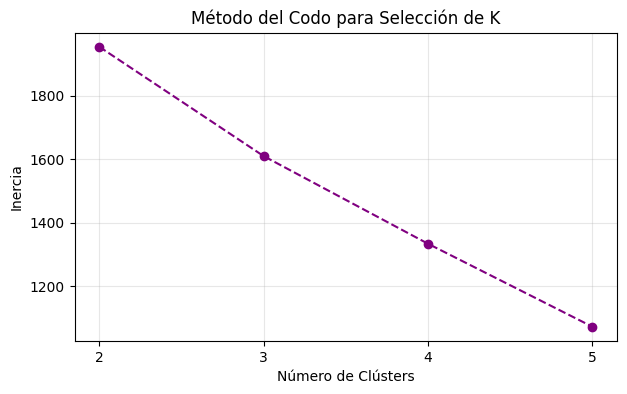

In [47]:
valores_k = [2, 3, 4, 5]
inercias = []
resultados = {}

for k in valores_k:
    bestCentroides, bestEtiquetas, bestInertia = runkMeans(X, k)
    inercias.append(bestInertia)
    # Guardamos los objetos para usarlos en el reporte posterior
    resultados[k] = {
        'centroides': bestCentroides,
        'etiquetas': bestEtiquetas,
        'inercia': bestInertia
    }
    print('La inercia fue de ', bestInertia, ' para K=', k)
plt.figure(figsize=(7, 4))
plt.plot(valores_k, inercias, marker='o', color='purple', linestyle='--')
plt.xlabel("Número de Clústers")
plt.ylabel("Inercia")
plt.title("Método del Codo para Selección de K")
plt.xticks(valores_k)
plt.grid(True, alpha=0.3)
plt.show()

[[-0.00670029 -0.21151984 -0.23455562 -0.03442131 -0.23360924 -0.09446257]
 [ 0.06349325  2.00440225  2.22269372  0.32618292  2.2137257   0.8951453 ]]


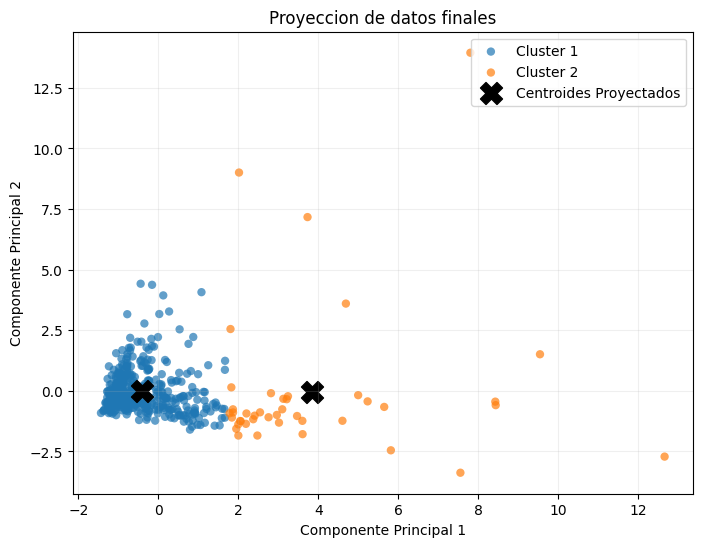

In [50]:
k_seleccionado = 2
etiquetas_finales = resultados[k_seleccionado]['etiquetas']
centroides_finales = resultados[k_seleccionado]['centroides']

print(centroides_finales)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)
centroides_2d = pca.transform(centroides_finales)

plt.figure(figsize=(8, 6))
for i in range(k_seleccionado):
    plt.scatter(X_2d[etiquetas_finales == i, 0], X_2d[etiquetas_finales == i, 1], label=f'Cluster {i+1}', alpha=0.7, edgecolors='none')
plt.scatter(centroides_2d[:, 0], centroides_2d[:, 1], color='black',  marker='X', s=250, label='Centroides Proyectados')
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Proyeccion de datos finales")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

Codigo: https://colab.research.google.com/drive/1FcK_CtrV61fQ9b87BJNepYxCTFx6OdoV?usp=sharing